#  AamaSuraksha - Pregnancy Risk Model Training
### Maternal Health Dataset · Random Forest Classifier

---

| Item | Detail |
|---|---|
| **Dataset** | `nepal_maternal_health_dataset.csv` — 1,200 patients |
| **Features** | 12 clinical features (Nepal/WHO-aligned) |
| **Algorithm** | Random Forest Classifier (scikit-learn) |
| **Output** | `trained_model.pkl`, `label_encoder.pkl`, `feature_columns.pkl` |
| **Reference** | Ahmed (2020) Maternal Health Risk Dataset + Nepal DHS 2022 + WHO SEARO |



---
## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported!')

All libraries imported!


---
## Load the Dataset

### Why this dataset is Nepal-specific:

| Feature | Nepal Context |
|---|---|
| `age` | 17% adolescent pregnancies (UNFPA Nepal 2022) |
| `weight_kg` | Avg rural Nepali woman ~50.5 kg (WHO SEARO) |
| `haemoglobin` | 42% anaemia in rural pregnant women (Nepal DHS 2022) |
| `blood_sugar` | Gestational diabetes ~10% (Nepal MOH) |
| `days_between_visits` | 72% rural women have <4 ANC visits total (Nepal DHS) |
| `systolic/diastolic_bp` | ~18% gestational hypertension (Nepal MOH 2023) |
| `prev_complications` | 28% previous obstetric complications |

> **Citation:** Adapted from Ahmed, M. (2020). *Maternal Health Risk Dataset*.
> UCI / Kaggle. Collected from rural hospitals, Bangladesh.
> Extended with Nepal DHS 2022 and WHO SEARO maternal health parameters.

In [2]:
df = pd.read_csv('nepal_maternal_health_dataset.csv')

print(f'Dataset loaded!')
print(f'   Rows    : {len(df)}')
print(f'   Columns : {len(df.columns)}')
print(f'   Columns : {list(df.columns)}')
print()

# Risk distribution
print('Risk Level Distribution:')
counts = df['risk_level'].value_counts()
for label, count in counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:6s} : {count:4d} patients ({pct:.1f}%)  {bar}')

print()
print(' First 5 rows:')
df.head()

Dataset loaded!
   Rows    : 1200
   Columns : 13
   Columns : ['age', 'weeks_pregnant', 'weight_kg', 'weight_gain_kg', 'systolic_bp', 'diastolic_bp', 'avg_systolic', 'avg_diastolic', 'blood_sugar', 'haemoglobin', 'days_between_visits', 'prev_complications', 'risk_level']

Risk Level Distribution:
  medium :  576 patients (48.0%)  ████████████████████████
  high   :  396 patients (33.0%)  ████████████████
  low    :  228 patients (19.0%)  █████████

 First 5 rows:


,age,weeks_pregnant,weight_kg,weight_gain_kg,systolic_bp,diastolic_bp,avg_systolic,avg_diastolic,blood_sugar,haemoglobin,days_between_visits,prev_complications,risk_level
0,26,4,50.1,1.0,123,81,112.5,77.0,5.10,5.2,41,0,medium
1,16,35,48.5,8.2,170,110,173.8,107.7,6.32,13.4,16,0,high
2,26,4,57.1,0.0,168,107,166.3,102.7,4.85,9.6,56,1,high
3,33,15,61.2,5.0,103,62,97.7,58.8,6.82,11.5,45,0,medium
4,21,36,60.6,13.4,131,87,126.7,89.1,5.26,13.7,42,1,medium


In [3]:
# Check for missing values
print('Missing values:', df.isnull().sum().sum(), '(should be 0)')
print()

# Mean values per risk group — show clinical logic
print('Average Clinical Values per Risk Group:')
print('=' * 65)
cols = ['age','systolic_bp','diastolic_bp','haemoglobin',
        'blood_sugar','days_between_visits','weight_kg']
print(df.groupby('risk_level')[cols].mean().round(1).to_string())

Missing values: 0 (should be 0)

Average Clinical Values per Risk Group:
             age  systolic_bp  diastolic_bp  haemoglobin  blood_sugar  days_between_visits  weight_kg
risk_level                                                                                           
high        27.2        136.6          89.1         10.5          5.9                 39.8       57.8
low         26.6        105.3          70.9         12.4          4.8                 20.6       57.0
medium      27.1        111.7          73.9         11.4          5.4                 34.2       57.5


---
## Exploratory Data Analysis (EDA)

C:\Users\A C E R\AppData\Local\Temp\ipykernel_26332\2526076461.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,2].boxplot(data_bp, labels=[r.capitalize() for r in order], patch_artist=True)
C:\Users\A C E R\AppData\Local\Temp\ipykernel_26332\2526076461.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  hb = axes[1,0].boxplot(data_hb, labels=[r.capitalize() for r in order], patch_artist=True)
C:\Users\A C E R\AppData\Local\Temp\ipykernel_26332\2526076461.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bs = axes[1,1].boxplot(data_bs, labels=[r.capitalize() for r in order], patch_artist=True)
C:\U

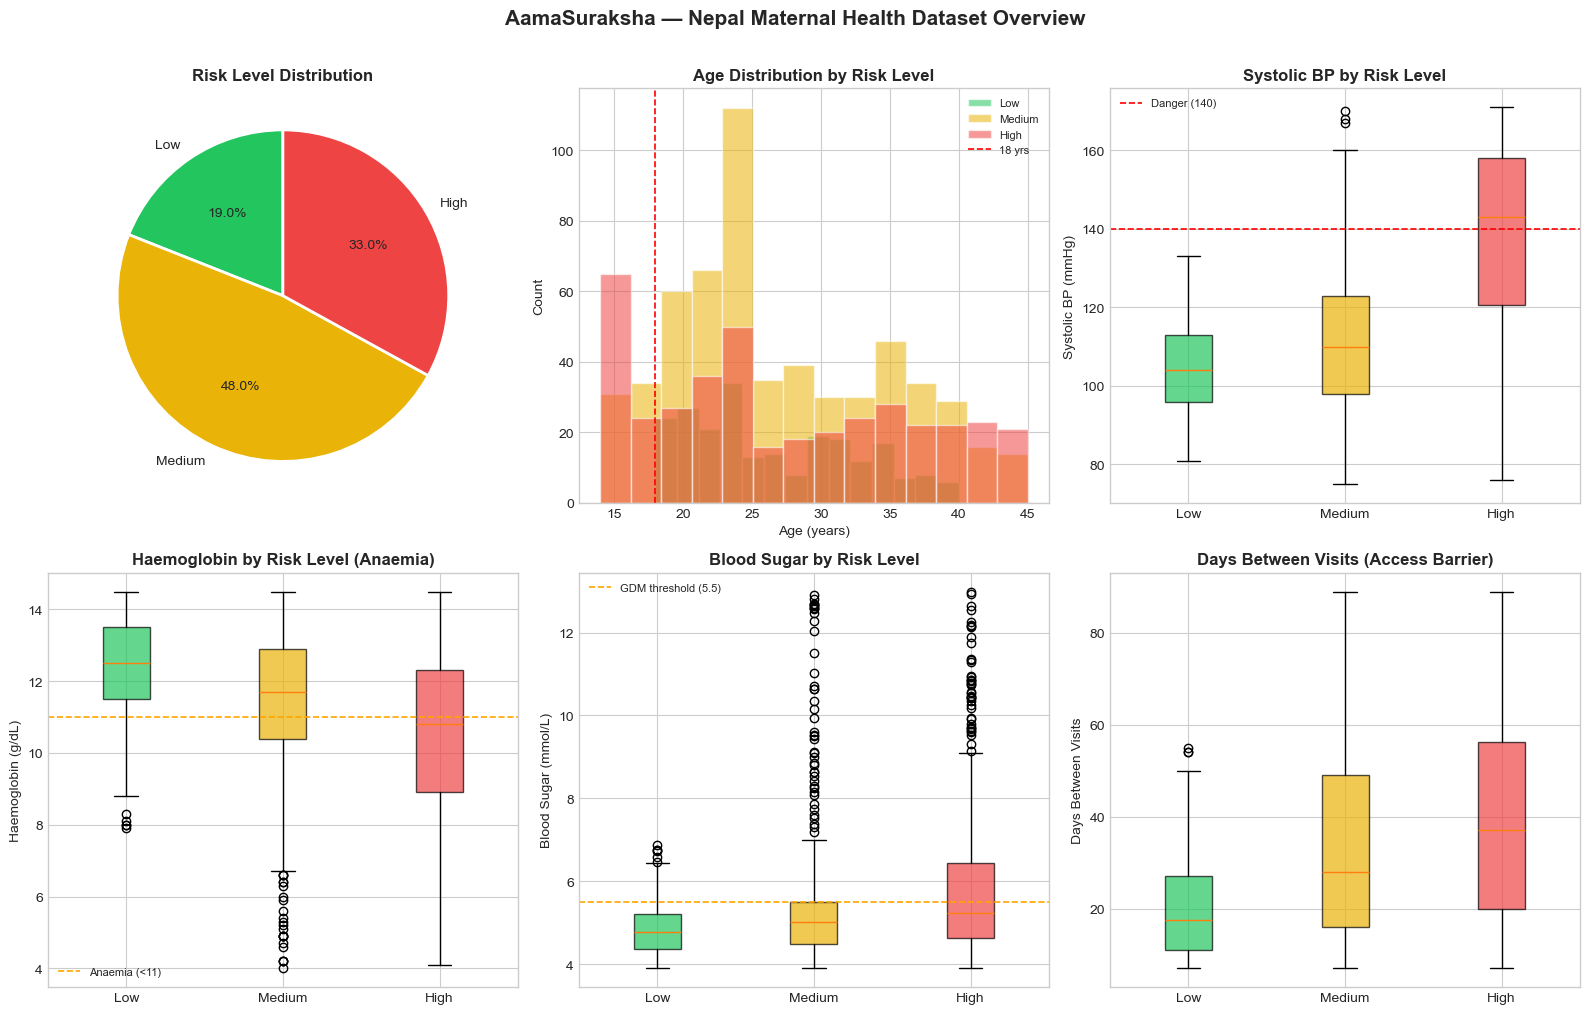

Saved: dataset_overview.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'AamaSuraksha — Nepal Maternal Health Dataset Overview',
    fontsize=15, fontweight='bold', y=1.01
)

colors   = {'low': '#22c55e', 'medium': '#eab308', 'high': '#ef4444'}
order    = ['low', 'medium', 'high']
c_list   = [colors[r] for r in order]

# 1 — Risk Level Pie
counts = df['risk_level'].value_counts()
axes[0,0].pie(
    [counts.get(r,0) for r in order],
    labels=[r.capitalize() for r in order],
    autopct='%1.1f%%',
    colors=c_list,
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[0,0].set_title('Risk Level Distribution', fontweight='bold')

# 2 — Age Histogram
for risk in order:
    axes[0,1].hist(
        df[df['risk_level']==risk]['age'],
        bins=14, alpha=0.55,
        label=risk.capitalize(),
        color=colors[risk], edgecolor='white'
    )
axes[0,1].axvline(18, color='red', linestyle='--', linewidth=1.2, label='18 yrs')
axes[0,1].set_title('Age Distribution by Risk Level', fontweight='bold')
axes[0,1].set_xlabel('Age (years)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=8)

# 3 — Systolic BP Boxplot
data_bp = [df[df['risk_level']==r]['systolic_bp'].values for r in order]
bp = axes[0,2].boxplot(data_bp, labels=[r.capitalize() for r in order], patch_artist=True)
for patch, clr in zip(bp['boxes'], c_list):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
axes[0,2].axhline(140, color='red', linestyle='--', linewidth=1.2, label='Danger (140)')
axes[0,2].set_title('Systolic BP by Risk Level', fontweight='bold')
axes[0,2].set_ylabel('Systolic BP (mmHg)')
axes[0,2].legend(fontsize=8)

# 4 — Haemoglobin Boxplot (Nepal-specific feature)
data_hb = [df[df['risk_level']==r]['haemoglobin'].values for r in order]
hb = axes[1,0].boxplot(data_hb, labels=[r.capitalize() for r in order], patch_artist=True)
for patch, clr in zip(hb['boxes'], c_list):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
axes[1,0].axhline(11.0, color='orange', linestyle='--', linewidth=1.2, label='Anaemia (<11)')
axes[1,0].set_title('Haemoglobin by Risk Level (Anaemia)', fontweight='bold')
axes[1,0].set_ylabel('Haemoglobin (g/dL)')
axes[1,0].legend(fontsize=8)

# 5 — Blood Sugar Boxplot
data_bs = [df[df['risk_level']==r]['blood_sugar'].values for r in order]
bs = axes[1,1].boxplot(data_bs, labels=[r.capitalize() for r in order], patch_artist=True)
for patch, clr in zip(bs['boxes'], c_list):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
axes[1,1].axhline(5.5, color='orange', linestyle='--', linewidth=1.2, label='GDM threshold (5.5)')
axes[1,1].set_title('Blood Sugar by Risk Level', fontweight='bold')
axes[1,1].set_ylabel('Blood Sugar (mmol/L)')
axes[1,1].legend(fontsize=8)

# 6 — Days Between Visits
data_dv = [df[df['risk_level']==r]['days_between_visits'].values for r in order]
dv = axes[1,2].boxplot(data_dv, labels=[r.capitalize() for r in order], patch_artist=True)
for patch, clr in zip(dv['boxes'], c_list):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
axes[1,2].set_title('Days Between Visits (Access Barrier)', fontweight='bold')
axes[1,2].set_ylabel('Days Between Visits')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_overview.png')

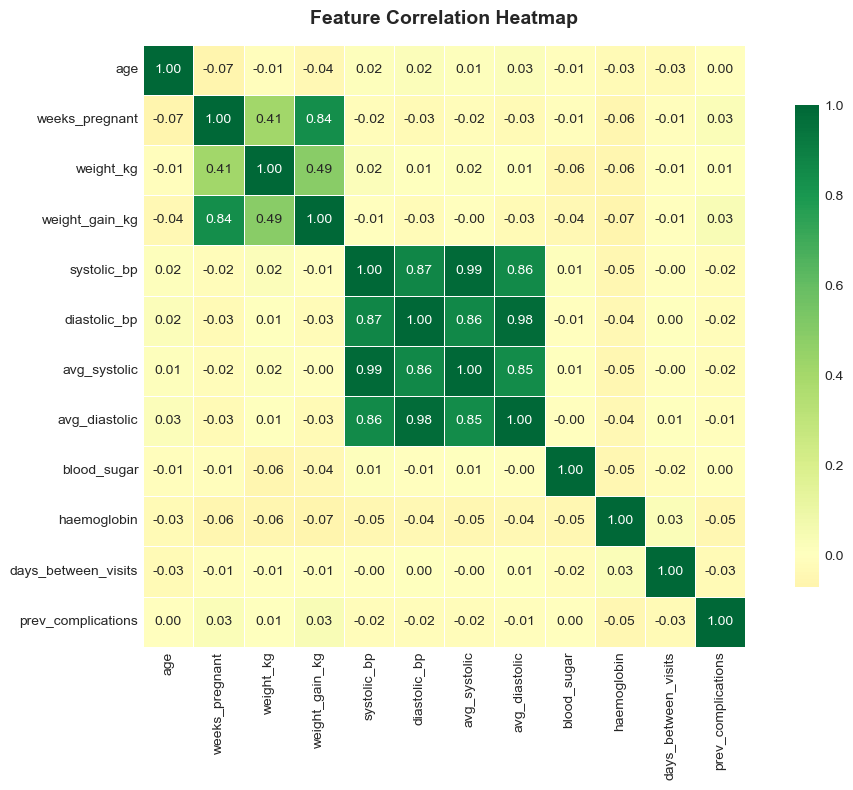

Saved: correlation_heatmap.png


In [5]:
# Correlation Heatmap
plt.figure(figsize=(11, 8))
numeric_df = df.drop('risk_level', axis=1)
sns.heatmap(
    numeric_df.corr(), annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

---
## Prepare Features and Labels

**X** = 12 clinical features &nbsp;|&nbsp; **y** = risk_level (low / medium / high)

Split: **80% training — 20% testing**

In [6]:
FEATURE_COLUMNS = [
    'weight_kg',
    'systolic_bp',
    'diastolic_bp',
    'age',
    'weeks_pregnant',
    'weight_gain_kg',
    'days_between_visits',
    'avg_systolic',
    'avg_diastolic',
    'blood_sugar',
    'haemoglobin',
    'prev_complications',
]

X      = df[FEATURE_COLUMNS].values
y_text = df['risk_level'].values

# Encode labels to numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

print('Features and labels prepared')
print(f'   X shape  : {X.shape}   (patients × features)')
print()
print('Label encoding map:')
for name, num in zip(encoder.classes_, range(len(encoder.classes_))):
    print(f'   "{name}"  →  {num}')

# 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print()
print(f'Data Split:')
print(f'   Training : {len(X_train)} patients  (80%)')
print(f'   Testing  : {len(X_test)}  patients  (20%)')

Features and labels prepared
   X shape  : (1200, 12)   (patients × features)

Label encoding map:
   "high"  →  0
   "low"  →  1
   "medium"  →  2

Data Split:
   Training : 960 patients  (80%)
   Testing  : 240  patients  (20%)


---
## Train the Random Forest Model

In [7]:
print('Training Random Forest Classifier...')
print('   150 trees · max depth 12 · balanced class weights')
print()

model = RandomForestClassifier(
    n_estimators  = 150,         # 150 decision trees
    max_depth     = 12,          # max tree depth
    random_state  = 42,
    class_weight  = 'balanced',  # handles class imbalance
    n_jobs        = -1           # use all CPU cores
)

model.fit(X_train, y_train)
print('Training complete!')

Training Random Forest Classifier...
   150 trees · max depth 12 · balanced class weights

Training complete!


---
## Evaluate the Model

In [8]:
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Test Set Accuracy : {accuracy * 100:.2f}%')
print()
print('Detailed Classification Report:')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Test Set Accuracy : 80.83%

Detailed Classification Report:
              precision    recall  f1-score   support

        high       0.88      0.71      0.78        79
         low       0.94      0.72      0.81        46
      medium       0.74      0.91      0.82       115

    accuracy                           0.81       240
   macro avg       0.85      0.78      0.81       240
weighted avg       0.83      0.81      0.81       240



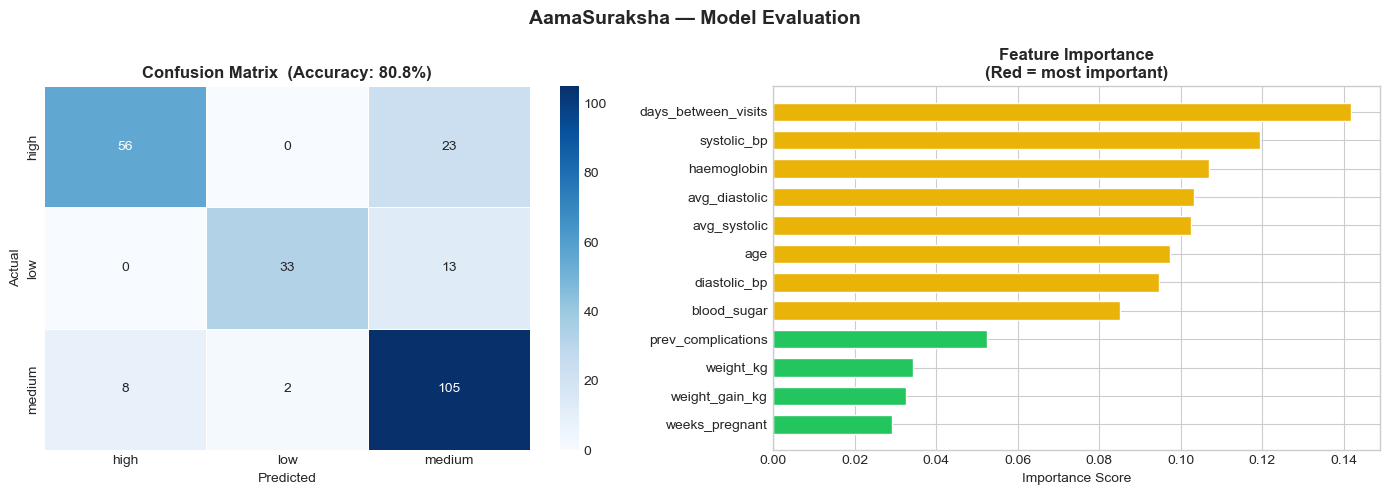

Saved: model_evaluation.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AamaSuraksha — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title(f'Confusion Matrix  (Accuracy: {accuracy*100:.1f}%)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance
imp_df = pd.DataFrame({
    'feature':    FEATURE_COLUMNS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

bar_colors = ['#ef4444' if v >= 0.15 else
              '#eab308' if v >= 0.08 else
              '#22c55e'
              for v in imp_df['importance']]

axes[1].barh(imp_df['feature'], imp_df['importance'],
             color=bar_colors, edgecolor='white', height=0.65)
axes[1].set_title('Feature Importance\n(Red = most important)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_evaluation.png')

In [10]:
# Manual prediction test 
print('Live Prediction Test')
print('=' * 50)

# Order must match FEATURE_COLUMNS exactly:
# weight_kg, systolic_bp, diastolic_bp, age, weeks_pregnant,
# weight_gain_kg, days_between_visits, avg_systolic, avg_diastolic,
# blood_sugar, haemoglobin, prev_complications

test_cases = [
    {
        'label'  : 'Healthy 24-yr-old (expect LOW)',
        'values' : [52.0, 110, 72, 24, 20, 3.5,  7, 108.0, 71.0, 4.8, 12.5, 0]
    },
    {
        'label'  : '37-yr-old with borderline BP + mild anaemia (expect MEDIUM)',
        'values' : [58.0, 132, 86, 37, 28, 6.0, 22, 130.0, 84.0, 5.6, 10.5, 0]
    },
    {
        'label'  : '16-yr-old, hypertension + severe anaemia + no visits (expect HIGH)',
        'values' : [43.0, 162, 106, 16, 32, 11.0, 65, 158.0, 102.0, 7.8, 6.5, 1]
    },
]

for case in test_cases:
    pred_num   = model.predict([case['values']])[0]
    pred_label = encoder.inverse_transform([pred_num])[0]
    proba      = model.predict_proba([case['values']])[0]

    icon = '✅' if pred_label == 'low' else '⚠️' if pred_label == 'medium' else '🚨'
    print(f"\n{case['label']}")
    print(f"   Prediction → {icon} {pred_label.upper()}")
    for cls, p in zip(encoder.classes_, proba):
        bar = '█' * int(p * 30)
        print(f"   {cls:6s}: {p*100:5.1f}%  {bar}")

Live Prediction Test

Healthy 24-yr-old (expect LOW)
   Prediction → ✅ LOW
   high  :   0.0%  
   low   :  94.7%  ████████████████████████████
   medium:   5.3%  █

37-yr-old with borderline BP + mild anaemia (expect MEDIUM)
   Prediction → ⚠️ MEDIUM
   high  :  23.3%  ██████
   low   :   4.4%  █
   medium:  72.3%  █████████████████████

16-yr-old, hypertension + severe anaemia + no visits (expect HIGH)
   Prediction → 🚨 HIGH
   high  :  99.3%  █████████████████████████████
   low   :   0.0%  
   medium:   0.7%  


---
## Save the Trained Model

In [11]:
os.makedirs('models', exist_ok=True)

with open('models/trained_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Saved: models/trained_model.pkl')

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print('Saved: models/label_encoder.pkl')

with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLUMNS, f)
print('Saved: models/feature_columns.pkl')

print()
print('=' * 55)
print('FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Algorithm     :  Random Forest Classifier')
print(f'  Trees         :  150')
print(f'  Max depth     :  12')
print(f'  Training rows :  {len(X_train)}')
print(f'  Test rows     :  {len(X_test)}')
print(f'  Accuracy      :  {accuracy * 100:.2f}%')
print(f'  Features (12) :  {FEATURE_COLUMNS}')
print(f'  Classes       :  {list(encoder.classes_)}')
print('=' * 55)
print()

Saved: models/trained_model.pkl
Saved: models/label_encoder.pkl
Saved: models/feature_columns.pkl

FINAL MODEL SUMMARY
  Algorithm     :  Random Forest Classifier
  Trees         :  150
  Max depth     :  12
  Training rows :  960
  Test rows     :  240
  Accuracy      :  80.83%
  Features (12) :  ['weight_kg', 'systolic_bp', 'diastolic_bp', 'age', 'weeks_pregnant', 'weight_gain_kg', 'days_between_visits', 'avg_systolic', 'avg_diastolic', 'blood_sugar', 'haemoglobin', 'prev_complications']
  Classes       :  ['high', 'low', 'medium']

